In [1]:
from itu.algs4.graphs.digraph import *
import matplotlib.pyplot as plt
import numpy as np

### 1. Leitura do arquivo

In [3]:
global G

with open("files/web-Stanford.txt", "r") as f:
    first_line = f.readline().strip().split()
    V = int(first_line[0])
    E = int(first_line[1])

    G = Digraph(V, first_index=1)

    for line in f:
        v, w = map(int, line.strip().split())
        G.add_edge(v, w)

with open("files/in_degree_list.txt", 'w') as f:
    f.write(G.in_degree_list())

with open("files/out_degree_list.txt", 'w') as f:
    f.write(G.out_degree_list())

with open("files/degree_list.txt", 'w') as f:
    f.write(G.degree_list())

print(f"Número de vértices: {G.V()}")
print(f"Número de arestas: {G.E()}")

Número de vértices: 281903
Número de arestas: 2312497


### 2. Densidade

In [4]:
density = G.density()
print(f"Densidade: {density:.7f}")

Densidade: 0.0000291


### 3. Distribuição de graus

In [5]:
global in_degrees, out_degrees, degrees

with open("files/in_degree_list.txt", 'r') as f:
    in_degrees = [int(line.strip().split(": ")[1]) for line in f.readlines()[1:]] 

with open("files/out_degree_list.txt", 'r') as f:
    out_degrees = [int(line.strip().split(": ")[1]) for line in f.readlines()[1:]]

with open("files/degree_list.txt", 'r') as f:
    degrees = [int(line.strip().split(": ")[1]) for line in f.readlines()[1:]]

### 4. Plot distribuição

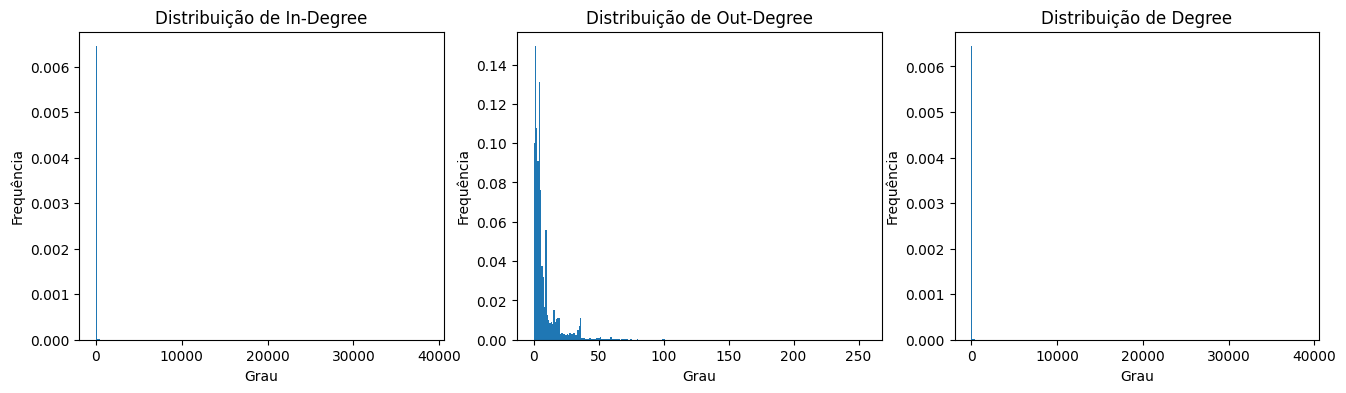

max in degree: 38606
min in degree: 0
max out degree: 255
min out degree: 0
max degree: 38626
min degree: 1


In [8]:
plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.hist(in_degrees, bins=250, density=True)
plt.title("Distribuição de In-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")

plt.subplot(1,3,2)
plt.hist(out_degrees, bins=250, density=True)
plt.title("Distribuição de Out-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")

plt.subplot(1,3,3)
plt.hist(degrees, bins=250, density=True)
plt.title("Distribuição de Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")

plt.show()

max_in_degree = max(in_degrees)
max_out_degree = max(out_degrees)

min_in_degree = min(in_degrees)
min_out_degree = min(out_degrees)

max_degree = max(degrees)
min_degree = min(degrees)

print(f"max in degree: {max_in_degree}\nmin in degree: {min_in_degree}")
print(f"max out degree: {max_out_degree}\nmin out degree: {min_out_degree}")
print(f"max degree: {max_degree}\nmin degree: {min_degree}")

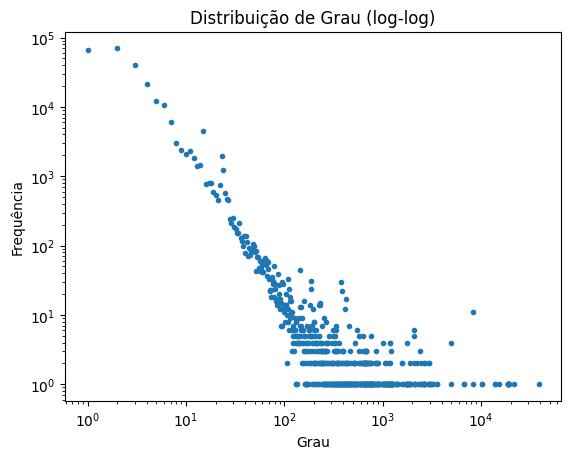

In [9]:
# Frequência acumulada
degree_count = np.bincount(in_degrees) # freq de cada grau
degrees = np.arange(len(degree_count)) # array de graus correspondente aos índices do degree_count

plt.figure()
plt.loglog(degrees[degree_count > 0], degree_count[degree_count > 0], marker=".", linestyle="None")
plt.title("Distribuição de Grau (log-log)")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.show()